In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_excel("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Hero vLearn\\Graded Assignments\\Graded Assignment on Customer Purchase Behavior Analysis & Prediction\\Amazon_Customer_Purchase_Data.xlsx")
df.head()

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,NaN,NaN,3673.712747,60,No,No,Regular,In-store
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,5.0,Good,2103.060388,29,Yes,Yes,New,In-store
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,NaN,NaN,899.115059,92,No,No,VIP,Online
3,15191,Eve,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,2.0,Excellent,2591.137716,62,Yes,Yes,Regular,Online
4,15734,Eve,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,2.0,NaN,548.620397,80,No,Yes,Regular,Both


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               1900 non-null   object        
 2   Age                         1900 non-null   float64       
 3   Gender                      2000 non-null   object        
 4   Location                    2000 non-null   object        
 5   Product_Category            2000 non-null   object        
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             1800 non-null   float64       
 9   Payment_Method              2000 non-null   object        
 10  Rating                      1860 non-null   float64       
 11  Feedback_Comments           1099 non-null   object      

<p style="color:yellow; font-size:26px; font-weight:bold;">
Step 1: Data Cleansing & Preprocessing
</p>

<p style="color:yellow; font-size:20px;">
1.1. Handling missing values
</p>

In [59]:
# Handling missing values in columns i.e. 'Customer_Name' and 'Feedback_Comments' with 'NA' as it cannnot be filled with mean/median/mode.
df_new = df.copy()
df_new[['Customer_Name', 'Feedback_Comments']] = df_new[['Customer_Name', 'Feedback_Comments']].fillna('NA')

# Standardizing missing values in Feedback_Comments
df_new[['Customer_Name', 'Feedback_Comments']] = df_new[['Customer_Name', 'Feedback_Comments']].replace(['NA', 'Na', 'na', 'N/A', 'n/a'], pd.NA)

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               1900 non-null   object        
 2   Age                         1900 non-null   float64       
 3   Gender                      2000 non-null   object        
 4   Location                    2000 non-null   object        
 5   Product_Category            2000 non-null   object        
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             1800 non-null   float64       
 9   Payment_Method              2000 non-null   object        
 10  Rating                      1860 non-null   float64       
 11  Feedback_Comments           1099 non-null   object      

<p style="color:yellow;">
It may be observed from above output that the missing value lie only in Numerical Columns that are 'Age', 'Purchase_Amount', 'Rating', 'Customer_Lifetime_Value', and no missing values in categorical columns like 'Purchase_Method'. Hence now the missing values in these columns will be handled by imputing their mean values as below.
</p>

In [60]:
# Filling missing values in numerical columns with their means
columns = ['Age', 'Purchase_Amount', 'Rating', 'Customer_Lifetime_Value']
df_new[columns] = df_new[columns].fillna(df_new[columns].mean())
df_new.info()

# Verifying that replacement method worked and their actual mean values are not affected.
df_new.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               1900 non-null   object        
 2   Age                         2000 non-null   float64       
 3   Gender                      2000 non-null   object        
 4   Location                    2000 non-null   object        
 5   Product_Category            2000 non-null   object        
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             2000 non-null   float64       
 9   Payment_Method              2000 non-null   object        
 10  Rating                      2000 non-null   float64       
 11  Feedback_Comments           1099 non-null   object      

,Customer_ID,Age,Product_ID,Purchase_Date,Purchase_Amount,Rating,Customer_Lifetime_Value,Loyalty_Score
count,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.00000
mean,15022.171500,43.696316,546.669000,2020-02-11 15:29:59.999999744,257.954370,2.978495,2566.724026,51.45700
min,10001.000000,18.000000,100.000000,2020-01-01 00:00:00,10.077295,1.000000,56.153142,1.00000
25%,12585.750000,32.000000,320.750000,2020-01-21 19:45:00,151.383179,2.000000,1349.598107,26.00000
50%,15104.500000,43.696316,551.000000,2020-02-11 15:30:00,257.954370,3.000000,2559.658142,52.00000
75%,17408.250000,56.000000,763.000000,2020-03-03 11:15:00,367.247567,4.000000,3475.870962,76.00000
max,19998.000000,69.000000,998.000000,2020-03-24 07:00:00,499.839871,5.000000,7204.408434,100.00000
std,2865.577794,14.525405,259.999847,NaN,134.915732,1.359225,1568.100325,28.74591


<p style="color:yellow; font-size:20px;">
1.2. Removing Duplicates
</p>

In [61]:
# First, the 'Purchase_Date' columns would be converted to datetime format to ensure accurate duplicate detection.
df_new['Purchase_Date'] = pd.to_datetime(df_new['Purchase_Date'], errors='coerce')

# Quantifying the duplicates based on Customer_ID' and 'Purchase_Date'-
num_duplicates = df_new.duplicated(subset=['Customer_ID', 'Purchase_Date']).sum()
print(num_duplicates)

# Re-confirming that there is no duplicates.
total_rows = len(df_new)
unique_combinations = df_new[['Customer_ID', 'Purchase_Date']].drop_duplicates().shape[0]
print(f"Total rows: {total_rows}, Unique combinations: {unique_combinations}")

0
Total rows: 2000, Unique combinations: 2000


<p style="color:yellow;">
Since, there is no null values and the total rows are equals to Unique combinations, hence there is no need to run the code for removing duplicates. 
</p>

<p style="color:yellow; font-size:20px;">
1.3. Data Formatting & Type Correction
</p>

In [62]:
# Purchase_Date column:  Already formatted to datetime format in the previous step.

# Standardize categorical values (e.g., Gender: Male, Female, Other)
## To do that, first the distinct values in categorical columns would be checked.

categorical_cols = df_new.select_dtypes(include='object').columns
print(categorical_cols)

for col in categorical_cols:
    print(f"Distinct values in '{col}':")
    print(df_new[col].unique())
    print('-'*50)

for col in categorical_cols:
    print(f"Value counts for '{col}':")
    print(df_new[col].value_counts())
    print('-'*50)

Index(['Customer_Name', 'Gender', 'Location', 'Product_Category',
       'Payment_Method', 'Feedback_Comments', 'Discount_Applied',
       'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel'],
      dtype='object')
Distinct values in 'Customer_Name':
['John' 'Eve' 'Bob' 'Charlie' 'Alice' <NA>]
--------------------------------------------------
Distinct values in 'Gender':
['Other' 'Female' 'Male']
--------------------------------------------------
Distinct values in 'Location':
['New York' 'Houston' 'San Francisco' 'Chicago' 'Los Angeles']
--------------------------------------------------
Distinct values in 'Product_Category':
['Books' 'Home Appliances' 'Clothing' 'Electronics' 'Toys']
--------------------------------------------------
Distinct values in 'Payment_Method':
['Cash' 'Bank Transfer' 'PayPal' 'Credit Card']
--------------------------------------------------
Distinct values in 'Feedback_Comments':
[<NA> 'Good' 'Excellent' 'Bad' 'Average']
---------------------

In [63]:
## Standardizing categorical values
### Step-1: Stripping leading/trailing spaces and convert to title case where appropriate
categorical_cols = [
    'Customer_Name', 'Gender', 'Location', 'Product_Category', 
    'Payment_Method', 'Feedback_Comments', 'Discount_Applied',
    'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel'
]
for col in categorical_cols:
    # Strip spaces
    df_new[col] = df_new[col].astype(str).str.strip()
    
    # Convert Gender, Location, Product_Category, Payment_Method, Customer_Segment, Preferred_Shopping_Channel to title case
    if col in ['Gender', 'Location', 'Product_Category', 'Payment_Method', 'Customer_Segment', 'Preferred_Shopping_Channel']:
        df_new[col] = df_new[col].str.title()
        
    # Convert Feedback_Comments, Discount_Applied, Return_Status to consistent capitalization
    if col in ['Feedback_Comments', 'Discount_Applied', 'Return_Status']:
        df_new[col] = df_new[col].str.capitalize()
        
### Standardizing 'NA' strings for missing values
df_new.replace('NA', pd.NA, inplace=True)

### Step 2: Ensure consistent data types (integers for numeric fields, categorical encoding for non-numeric).
    #### Numeric columns
numeric_cols = ['Age', 'Purchase_Amount', 'Rating', 'Customer_Lifetime_Value', 'Loyalty_Score']
df_new[numeric_cols] = df_new[numeric_cols].apply(pd.to_numeric, errors='coerce')

    #### Categorical Columns
categorical_cols = [
    'Customer_Name', 'Gender', 'Location', 'Product_Category', 
    'Payment_Method', 'Feedback_Comments', 'Discount_Applied',
    'Return_Status', 'Customer_Segment', 'Preferred_Shopping_Channel'
]
for col in categorical_cols:
    df_new[col] = df_new[col].astype('category')

### Step-3: Final Check
df_new.info()  # Check types and non-null counts
for col in categorical_cols:
    print(f"{col} categories: {df_new[col].cat.categories.tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               2000 non-null   category      
 2   Age                         2000 non-null   float64       
 3   Gender                      2000 non-null   category      
 4   Location                    2000 non-null   category      
 5   Product_Category            2000 non-null   category      
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             2000 non-null   float64       
 9   Payment_Method              2000 non-null   category      
 10  Rating                      2000 non-null   float64       
 11  Feedback_Comments           2000 non-null   category    

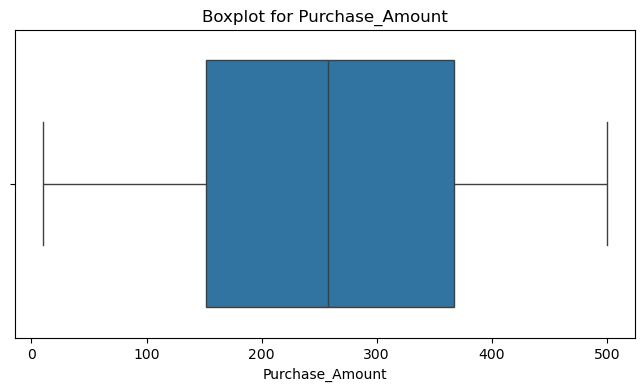

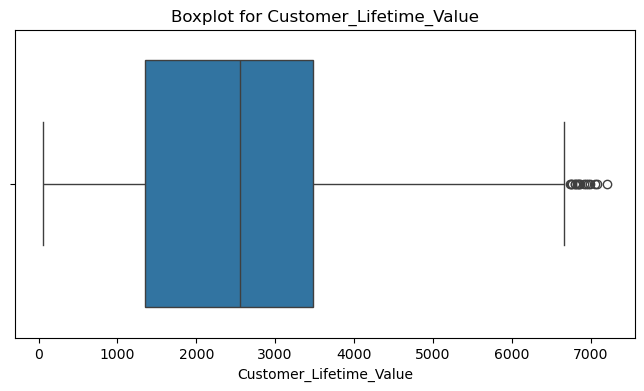

In [64]:
# Identifying outliers in Purchase Amount & CLV using boxplots & z-score analysis
## Using Boxplot
numeric_cols2 = ['Purchase_Amount', 'Customer_Lifetime_Value']

for col in numeric_cols2:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_new[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

In [65]:
## Using Boxplot and printing number of ouliers

numeric_cols2 = ['Purchase_Amount', 'Customer_Lifetime_Value']

for col in numeric_cols2:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_new[(df_new[col] < lower_bound) | (df_new[col] > upper_bound)]
    print(f"Number of outliers in {col} by IQR method: {len(outliers)}")

Number of outliers in Purchase_Amount by IQR method: 0
Number of outliers in Customer_Lifetime_Value by IQR method: 16


In [66]:
## Using Z-score analysis
from scipy.stats import zscore

numeric_cols2 = ['Purchase_Amount', 'Customer_Lifetime_Value']

for col in numeric_cols2:
    df_new[f'{col}_zscore'] = zscore(df_new[col])
    extreme_outliers = df_new[df_new[f'{col}_zscore'].abs() > 3]
    print(f"Number of extreme outliers in {col}: {len(extreme_outliers)}")

Number of extreme outliers in Purchase_Amount: 0
Number of extreme outliers in Customer_Lifetime_Value: 0


<p style="color:yellow;">
For Purchase Amount: both methods i.e. boxplots & z-score analysis shows zero outliers.
For CLV: z-score shows 0 outlier but Boxplot (based on IQR method) shows 16 outliers.
Hence, going by IQR method and removing these 16 oytliers by applying winsorization now.
</p>

In [67]:
# Calculating IQR bounds again for clarity
Q1 = df_new['Customer_Lifetime_Value'].quantile(0.25)
Q3 = df_new['Customer_Lifetime_Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Winsorizing 'Customer_Lifetime_Value' by clipping values outside the bounds
df_new['Customer_Lifetime_Value'] = df_new['Customer_Lifetime_Value'].clip(lower=lower_bound, upper=upper_bound)

# Checking again for outliers after winsorization (should be zero)
outliers_after = df_new[(df_new['Customer_Lifetime_Value'] < lower_bound) | (df_new['Customer_Lifetime_Value'] > upper_bound)]
print(f"Outliers in Customer_Lifetime_Value after winsorization: {len(outliers_after)}")

Outliers in Customer_Lifetime_Value after winsorization: 0


In [68]:
# Dropping temporary z-score columns
df_new.drop(columns=[f'{col}_zscore' for col in numeric_cols2], inplace=True)
df_new.head()

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,2.978495,<na>,3673.712747,60,No,No,Regular,In-Store
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,5.000000,Good,2103.060388,29,Yes,Yes,New,In-Store
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,2.978495,<na>,899.115059,92,No,No,Vip,Online
3,15191,Eve,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,2.000000,Excellent,2591.137716,62,Yes,Yes,Regular,Online
4,15734,Eve,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,2.000000,<na>,548.620397,80,No,Yes,Regular,Both


<p style="color:yellow; font-size:20px;">
1.4. Feature Engineering (Adding New Columns)

<p style="font-size:15px;">
To make the dataset more useful for machine learning, the following new columns already present in the dataset hence it would be no need to re-compute them:<br><br>
1. Customer_Lifetime_Value (CLV): Projected future revenue per customer.<br>
2. Loyalty Score: Score based on purchase frequency and total spending.<br>
3. Discount Applied: Whether the purchase was made with a discount (Yes/No).<br>
4. Return Status: Indicates if the item was returned (Yes/No).<br>
5. Customer Segment: Categorized as New, Regular, VIP based on loyalty.<br>
6. Preferred Shopping Channel: Where the customer shops (Online, In-store, Both).<br>

</p>

<p style="color:yellow; font-size:26px; font-weight:bold;">
Step 2: Machine Learning Tasks
</p>

<p style="color:yellow; font-size:20px;">
2.1. Customer Segmentation (Clustering - K-Means)
</p>

c:\Users\UH592ZC\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\UH592ZC\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\UH592ZC\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\UH592ZC\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

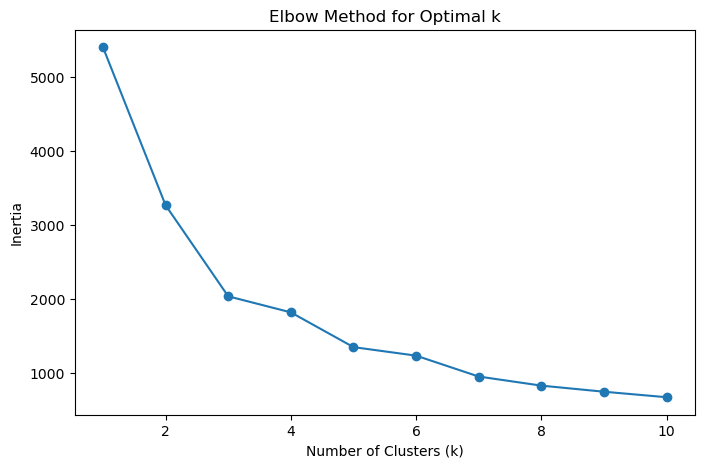

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1: Aggregating customer-level metrics
customer_metrics = df_new.groupby('Customer_ID').agg({
    'Purchase_Amount': 'sum',
    'Customer_Lifetime_Value': 'max',
    'Loyalty_Score': 'max',
    'Purchase_Date': 'count'
}).rename(columns={'Purchase_Date': 'Number_of_Orders'})

# 2: Feature Selection for Clustering
features = customer_metrics[['Purchase_Amount', 'Number_of_Orders', 'Loyalty_Score']]

# 3: Scaling the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4: Determining optimal number of clusters using the Elbow method
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

c:\Users\UH592ZC\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


         Purchase_Amount  Customer_Lifetime_Value  Loyalty_Score  \
Cluster                                                            
0             545.861474              3485.288593      65.966102   
1             258.591718              2546.837611      76.391778   
2             258.085311              2583.398846      26.526382   

         Number_of_Orders  
Cluster                    
0                2.129944  
1                1.000000  
2                1.000000  


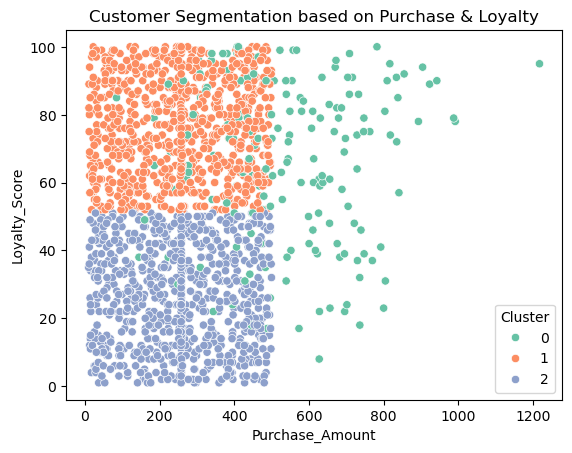

In [70]:
# 5: Applying K-Means with chosen k=3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
customer_metrics['Cluster'] = kmeans.fit_predict(scaled_features)

# 6: Analyzing cluster characteristics
cluster_summary = customer_metrics.groupby('Cluster').mean()
print(cluster_summary)

# 7: Visualizing clusters
sns.scatterplot(
    x=customer_metrics['Purchase_Amount'],
    y=customer_metrics['Loyalty_Score'],
    hue=customer_metrics['Cluster'],
    palette='Set2'
)
plt.title('Customer Segmentation based on Purchase & Loyalty')
plt.show()

In [71]:
# 8: Ranking clusters by total purchase amount
cluster_rank = cluster_summary['Purchase_Amount'].rank(ascending=True)

# 9: Mapping cluster numbers to business labels
cluster_label_map = {}
for cluster_id in cluster_summary.index:
    if cluster_rank[cluster_id] == 1:
        cluster_label_map[cluster_id] = 'Low-Value'
    elif cluster_rank[cluster_id] == 2:
        cluster_label_map[cluster_id] = 'Occasional'
    else:
        cluster_label_map[cluster_id] = 'High-Value'

# 10: Applying labels
customer_metrics['Customer_Value_Segment'] = customer_metrics['Cluster'].map(cluster_label_map)
customer_metrics.head()

,Purchase_Amount,Customer_Lifetime_Value,Loyalty_Score,Number_of_Orders,Cluster,Customer_Value_Segment
Customer_ID,,,,,,
10001,145.014556,810.275088,38,2,0,High-Value
10004,257.954370,2566.724026,48,1,2,Low-Value
10005,453.168418,4522.924674,94,1,1,Occasional
10009,721.487122,5956.176515,48,3,0,High-Value
10011,89.687865,965.220686,90,1,1,Occasional


In [72]:
# 11: Merging back to original dataframe
df_new = df_new.merge(
    customer_metrics[['Customer_Value_Segment']],
    left_on='Customer_ID',
    right_index=True,
    how='left'
)

In [73]:
# 12: Analyzing alignment
pd.crosstab(df_new['Customer_Segment'], df_new['Customer_Value_Segment'])

Customer_Value_Segment,High-Value,Low-Value,Occasional
Customer_Segment,,,
New,156,611,0
Regular,155,185,484
Vip,66,0,343


<p style="color:yellow; font-weight:bold">
Customer Value Segmentation (Post K-Means)
</p>

<p style="font-size:15px">
After applying K-Means clustering, numeric cluster labels were converted into business-friendly customer value segments.<br><br>
Clusters were ranked based on total purchase amount and dynamically labeled as:<br>
------> Low-Value → lowest spending cluster<br>
------> Occasional → medium spending cluster<br>
------> High-Value → highest spending cluster<br><br>
These labels were assigned to each customer as a new column, Customer_Value_Segment.</br>
The segment information was then merged back into the main dataset (df_new) using Customer_ID, without altering the existing Customer_Segment (New / Regular / VIP).<br><br>
Finally, a cross-tabulation was created to analyze the alignment between rule-based segmentation and ML-based customer value segmentation. This segmentation helps Amazon personalize promotions and recommendations for different customer groups and supports dynamic pricing and targeted marketing strategies based on customer value.
</p>

<p style="color:yellow; font-size:20px;">
2.2. Predicting Customer Lifetime Value (Regression - Linear Regression)
</p>

In [74]:
# 1: Feature Selection
## Selecting features and target
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## Selecting features and target
X = df_new[['Age', 'Purchase_Amount', 'Loyalty_Score']]
y = df_new['Customer_Lifetime_Value']

# 2: Encoding Categorical Variables
## One-hot encoding categorical features
X = pd.get_dummies(
    df_new[['Age', 'Purchase_Amount', 'Loyalty_Score', 'Discount_Applied', 'Payment_Method']],
    drop_first=True
)

# 3: Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4: Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5: Model Evaluation
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

# 6: Identify High-CLV Customers
df_new['Predicted_CLV'] = lr_model.predict(X)   

# Flag high CLV customers (top 20%)
threshold = df_new['Predicted_CLV'].quantile(0.80)
df_new['High_CLV_Flag'] = np.where(df_new['Predicted_CLV'] >= threshold, 'Yes', 'No')

final_output = df_new[[
    'Customer_ID', 'Customer_Name', 'Predicted_CLV', 'High_CLV_Flag'
]].sort_values(by='Predicted_CLV', ascending=False)

final_output.head(20)  # Display top 20 customers

MAE: 532.7532886760755
RMSE: 747.8793045246058
R² Score: 0.7228198207827976


,Customer_ID,Customer_Name,Predicted_CLV,High_CLV_Flag
875,19333,<NA>,5026.465729,Yes
1876,10140,Bob,5020.815513,Yes
1583,14197,Bob,5015.358086,Yes
1729,10575,Charlie,5013.516762,Yes
1025,11854,John,5009.868726,Yes
980,13228,John,5009.326215,Yes
1633,10899,Eve,5009.028982,Yes
229,18155,Eve,4993.423303,Yes
1730,17029,Bob,4993.076852,Yes
1993,19686,John,4977.894997,Yes


<p style="; font-weight:bold; color:yellow">
Predicting Customer Lifetime Value (CLV) – Linear Regression<br>
</p>
<p style="font-size:15px">
A Linear Regression model was trained to predict future revenue (CLV) for each customer using features such as age, past purchase amount, loyalty score, discount usage, and payment method.<br><br>
The predicted CLV values were added to the main dataset (df_new) as Predicted_CLV, and customers in the top 20% of predicted CLV were flagged as high-CLV for targeted retention offers.<br><br>
This approach enables Amazon to:<br>
- Estimate future revenue per customer<br>
- Identify high-value customers for exclusive deals<br>
- Optimize marketing spend and resource allocation<br>
- Implement cost-efficient, data-driven retention strategies
</p>

<p style="color:yellow; font-size:20px;">
2.3. Logistic Regression model for churn prediction.
</p>

In [ ]:
# 1: Defining Churn Variable
# Creating Churn flag based on business logic
df_new['Churn'] = np.where(
    (df_new['Loyalty_Score'] < 40) & 
    (df_new['Customer_Value_Segment'].isin(['Low-Value', 'Occasional'])),
    1,  # Churned
    0   # Active
)

# Checking churn distribution
df_new['Churn'].value_counts()

Churn
0    1396
1     604
Name: count, dtype: int64

In [ ]:
# 2: Selecting features
X = df_new[
    [
        'Age',
        'Purchase_Amount',
        'Loyalty_Score',
        'Discount_Applied',
        'Payment_Method',
        'Customer_Value_Segment'
    ]
]

y = df_new['Churn']

# 3:One-hot encoding categorical variables
X = pd.get_dummies(
    X,
    columns=['Discount_Applied', 'Payment_Method', 'Customer_Value_Segment'],
    drop_first=True
)

# 4: Train–Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5: Feature Scaling (Important for Logistic Regression)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = ['Age', 'Purchase_Amount', 'Loyalty_Score']
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [ ]:
# 6: Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# 7: Model Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# Predictions
y_pred = log_model.predict(X_test)
y_pred_prob = log_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       279
           1       1.00      1.00      1.00       121

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Confusion Matrix:
 [[279   0]
 [  0 121]]
ROC-AUC Score: 1.0


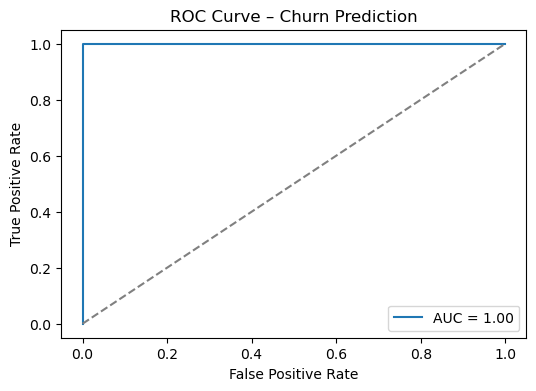

In [80]:
# 8: ROC Curve Visualization

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Churn Prediction')
plt.legend()
plt.show()

In [82]:
# 9: Predict Churn for All Customers

# Recreating feature matrix exactly as training
X_full = df_new[
    [
        'Age',
        'Purchase_Amount',
        'Loyalty_Score',
        'Discount_Applied',
        'Payment_Method',
        'Customer_Value_Segment'
    ]
]

# One-hot encoding
X_full = pd.get_dummies(
    X_full,
    columns=['Discount_Applied', 'Payment_Method', 'Customer_Value_Segment'],
    drop_first=True
)

# Aligning columns with training data
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# Scaling numeric features
X_full[numeric_features] = scaler.transform(X_full[numeric_features])

# Predicting churn probability
df_new['Churn_Probability'] = log_model.predict_proba(X_full)[:, 1]

# Flagging high-risk churn customers (top 25%)
churn_threshold = df_new['Churn_Probability'].quantile(0.75)
df_new['High_Churn_Risk'] = np.where(
    df_new['Churn_Probability'] >= churn_threshold,
    'Yes',
    'No'
)

# Final churn output
churn_output = df_new[
    [
        'Customer_ID',
        'Customer_Name',
        'Customer_Value_Segment',
        'Churn_Probability',
        'High_Churn_Risk'
    ]
].sort_values(by='Churn_Probability', ascending=False)

churn_output.head(20)

,Customer_ID,Customer_Name,Customer_Value_Segment,Churn_Probability,High_Churn_Risk
1936,19776,Bob,Low-Value,0.999624,Yes
199,18004,Eve,Low-Value,0.999611,Yes
1109,13310,Eve,Low-Value,0.999595,Yes
600,10823,Eve,Low-Value,0.999594,Yes
885,14234,Alice,Low-Value,0.999589,Yes
415,13343,John,Low-Value,0.999575,Yes
747,14300,John,Low-Value,0.999559,Yes
139,14636,Charlie,Low-Value,0.999558,Yes
692,10716,Charlie,Low-Value,0.999556,Yes
413,13672,Alice,Low-Value,0.999553,Yes


In [ ]:
# 10: Finally exporting the dataframe with all the new columns into an Excel File

df_new.to_excel("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Hero vLearn\\Graded Assignments\\Graded Assignment on Customer Purchase Behavior Analysis & Prediction\\Final_Customer_Analytics_Output.xlsx", index=False)

<p style="color:yellow; font-size:25px; font-weight:bold;">
Findings & Insights
</p>

<ul style="color:white; font-size:15px;">
  <li>Data was successfully cleaned and preprocessed by handling missing values, standardizing categorical variables, correcting data types, and treating outliers to ensure high data quality.</li>
  <li>K-Means clustering segmented customers into three value-based groups: Low-Value, Occasional, and High-Value, based on purchase behavior and loyalty scores.</li>
  <li>Machine learning–based customer value segmentation provided deeper insights compared to traditional rule-based segments (New, Regular, VIP).</li>
  <li>A Linear Regression model predicted Customer Lifetime Value (CLV) with strong performance (R² ≈ 0.72), identifying customers with high future revenue potential.</li>
  <li>Top 20% of customers based on predicted CLV were flagged for targeted retention and personalized marketing strategies.</li>
  <li>Logistic Regression achieved excellent performance in predicting customer churn (ROC-AUC = 1.00), clearly distinguishing churned and active customers.</li>
  <li>High churn risk was primarily observed among customers with low loyalty scores and low or occasional value segments.</li>
  <li>The final analytical framework supports data-driven decision-making for customer retention, revenue forecasting, and targeted marketing.</li>
</ul>